**_二分查找算法的三种形式（红蓝染色法）：_**

对于二分算法而言，区间左侧的值小于k，区间右边的值大于等于k，区间里面值的属性未知，使用lower_pound会把整个数组染色为红蓝两部分，并返回第一个大于等于k的数的索引，因此循环的结束条件一定是区间内没有元素了，针对左闭右闭，左闭右开以及左开右开的结束条件以及返回的值也就会有所不同，下面详细介绍：

In [ ]:
#形式一（左闭右闭型）
#使用左闭右闭形式时，区间左侧的值<target，区间右侧的值>=target,而[left,right]两个左右指针因为仍在区间内，所以它们所指向元素的属性未知，结束条件为left>right，区间内就没有元素了，最终right+1或者说left就是我们要找的值。
def lower_pound1(nums,target):
    left = 0
    right = len(nums) - 1
    while left <= right:
        mid = (left + right) // 2
        if target > nums[mid]:
            left = mid + 1 #左右指针要指向没有处理的元素，因为mid已经被处理，所以存在+1与-1将其排除
        else:
            right = mid - 1
    return right + 1 # left

In [ ]:
#形式二（左闭右开型）
#这种形式下区间左右侧值的属性与形式一相同，[left,right)形式下right指向mid那么区间内的元素都是未经处理的，left指向元素属性未知，而right指向的值>=target，结束条件为left==right，区间无元素，left或者right就是我们要找的值。
def lower_pound2(nums,target):
    left = 0
    right = len(nums)
    while left < right:
        mid = (left + right) // 2
        if target > nums[mid]:
            left = mid + 1
        else:
            right = mid
    return left #right

In [ ]:
#形式三（左开右开型）
#(left,right),其中left与right指向的都是已经处理过的元素，这样才能保证区间外的元素都是被处理过的，结束条件为left+1 = right，此时区间内无元素，left+1或者right就是我们要找的值
def lower_pound3(nums,target):
    left = -1
    right = len(nums)
    while left + 1 < right:
        mid = (left + right) // 2
        if target > nums[mid]:
            left = mid
        else:
            right = mid

 [或者]指向的元素一定是没有被处理过的，而(或者)指向的元素一定是被处理过的。所以对于有开括号的形式而言，由于最开始没有处理过的元素，因此可以让left指向-1(值为无穷小)，right指向len(n)值为无穷大

    找到第一个>=x的值：lower_pound(x)
    找到最后一个<x的值：lower_pound(x) - 1
    找到第一个>x的值 ：lower_pound(x+1)
    找到最后一个<=x的值：lower_pound(x+1) - 1

**_#1.搜索旋转排序数组_**

数组是部分有序的，所以问题的关键变成了判断数组的有序部分

In [ ]:
class Solution:
    def search(self, nums, target: int) -> int:
        def isblue(mid,end,target):#红蓝染色法，其中，红色代表target的左侧，蓝色代表target以及它的右侧
            if mid > end:#通过这个函数判断在右侧的情况，剩下的就是红色的情况
                return end < target <= mid
            else:
                return target > end or target <= mid

        left,right = 0,len(nums)-2
        end = nums[-1]
        while left <= right:
            mid = (left + right) // 2
            if isblue(nums[mid],end,target):
                right = mid - 1
            else:
                left = mid + 1
        if left == len(nums) or nums[left] != target:
            return -1
        else:
            return left

**_#2.寻找旋转数组中的最小值_**

旋转数组左半部分的元素一定大于右半部分，令中间值与末尾值进行比较，如果中间值大于end，意味着中间值及其左侧的值都在最小值的左侧，染成红色，否则为蓝色，蓝色代表着最小值及其右侧。

In [ ]:
class Solution:
    def findMin(self, nums) -> int:
        n = len(nums)
        left,right = 0,n - 1
        end = nums[-1]
        while left <= right:
            mid = (left + right) // 2
            if nums[mid] > end:
                left = mid + 1
            else:
                right = mid - 1
        return nums[left]

**_#3.在排序数组中查找元素的第一个位置和最后一个位置_**

思想：对于查找最左边元素而言，当前的中值等于目标值的话让右指针左移，退出时left指向的元素就是第一个位置

In [ ]:
class Solution(object):
    def searchRange(self, nums, target):
        """
        :type nums: List[int]
        :type target: int
        :rtype: List[int]
        """
        left = 0
        right = len(nums)-1
        length = len(nums)

        while left<=right:
            mid = (left+right)//2
            if nums[mid]<target:
                left = mid + 1
            else:
                right = mid - 1
        num1 = left
        if left >=length or nums[left]!=target:
            return [-1,-1]

        left = 0
        right = len(nums)-1
        while left<=right:
            mid = (left+right)//2
            if nums[mid]<=target:
                left = mid + 1
            else:
                right = mid - 1

        return[num1,right]

#4.寻找峰顶

红蓝染色法：红色代表峰顶左侧，蓝色代表峰顶以及峰顶右侧

In [ ]:
class Solution(object):
    def findPeakElement(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        left = -1
        right = len(nums)-1 #开区间写法时左右指针指向已经确定的元素

        while left + 1 < right:
            mid = (left + right) // 2
            if nums[mid] > nums[mid+1]:#当 nums【mid】 > nums【mid + 1】 时，mid要么是峰顶（它比mid - 1大）；要么是在峰顶右侧（它比mid -1 小）。所以这时我们 right = mid时，是表示 right 及其右侧是在 “某一个”峰顶的右侧，而不是说right及其右侧没有峰顶！
                right = mid
            else:#当 nums【mid】 < nums【mid + 1】 时，mid是在“某一个”封顶的左侧，它及它左侧是在“某一个”峰顶的左侧。此时一定有峰顶在右侧
                left = mid
        return right

**_#5.荷兰国旗方法（简化版的三路快速排序）_**

In [ ]:
class Solution(object):
    def sortColors(self, nums):
        """
        :type nums: List[int]8
        :rtype: None Do not return anything, modify nums in-place instead.
        """
        left = 0
        right = len(nums) - 1

        lt = left - 1
        i = 0
        gt = right + 1

        while i < gt:
            if nums[i] < 1:
                lt += 1
                nums[i], nums[lt] = nums[lt],nums[i]
                i += 1
            elif nums[i] == 1:
                i += 1
            else:
                gt -= 1
                nums[i],nums[gt] = nums[gt],nums[i]

**_#6.查找两个正序数组的中位数_**
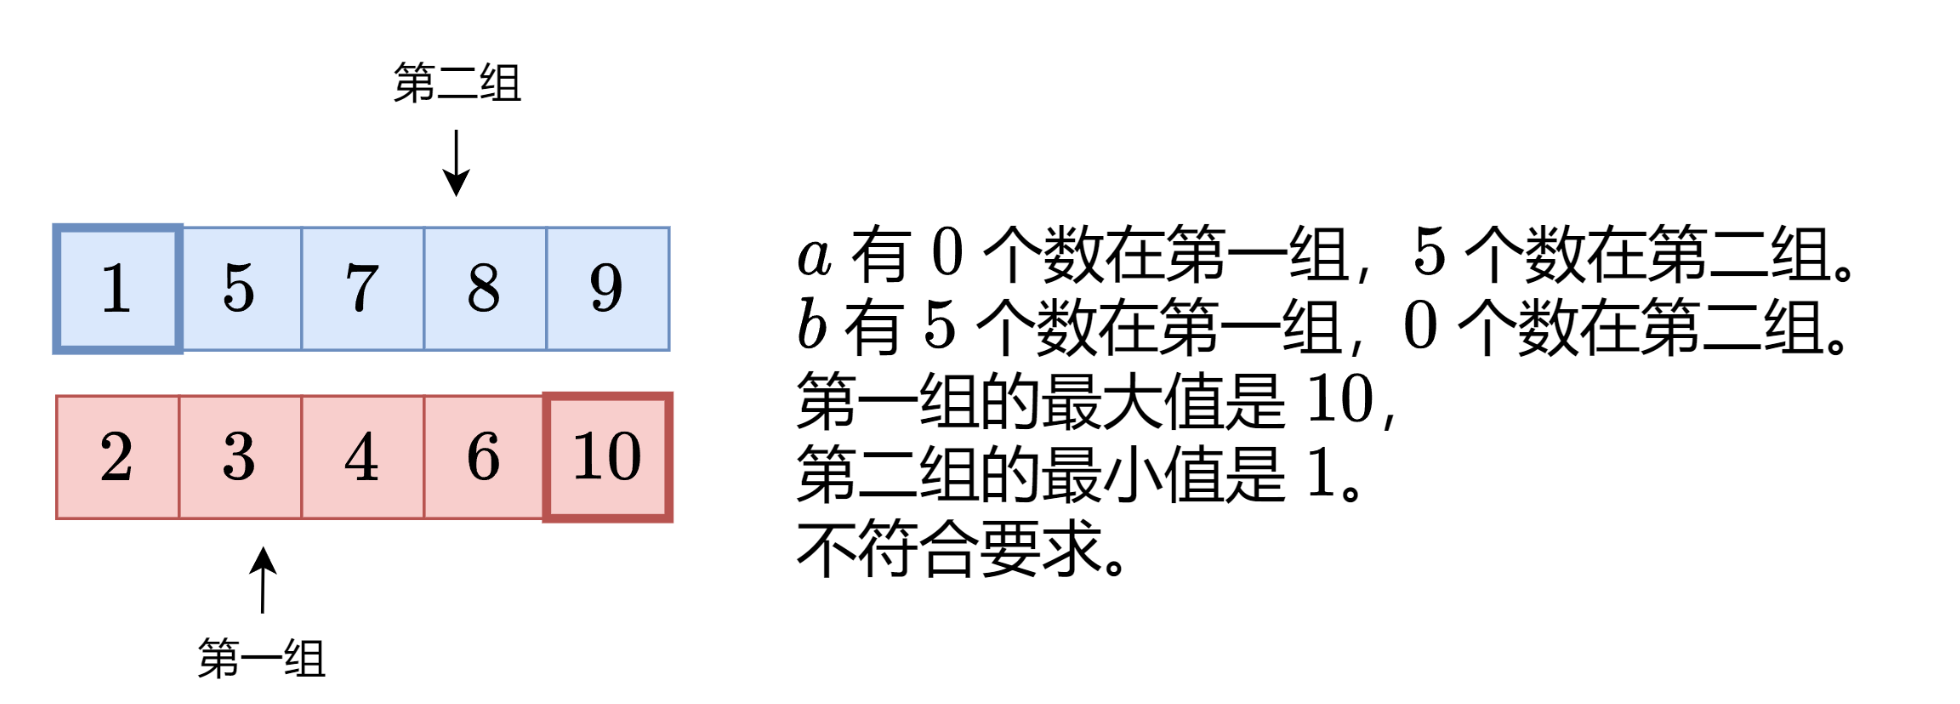

     ai:数组a在第一组（左半部分）的最大值
     bi:数组b在第一组的最大值
     a[i+1]:数组a在第二组（右半部分）的最小值
     b[j+1]:数组b在第二组的最小值

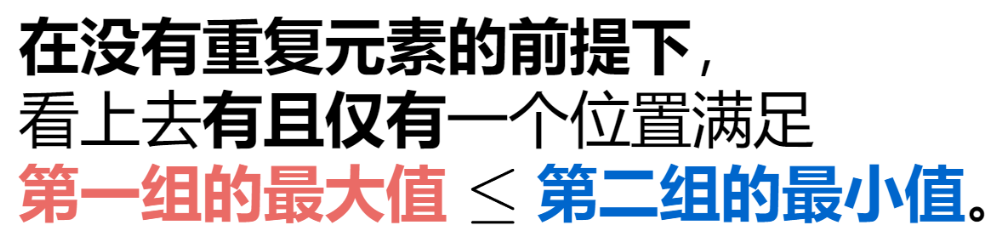

只要能证明左半部分的最大值小于右半部分的最小值，那么中位数我们也就找到了

左半部分（第一组）的元素个数要么等于右半部分（第二组），要么比右半部分多1。

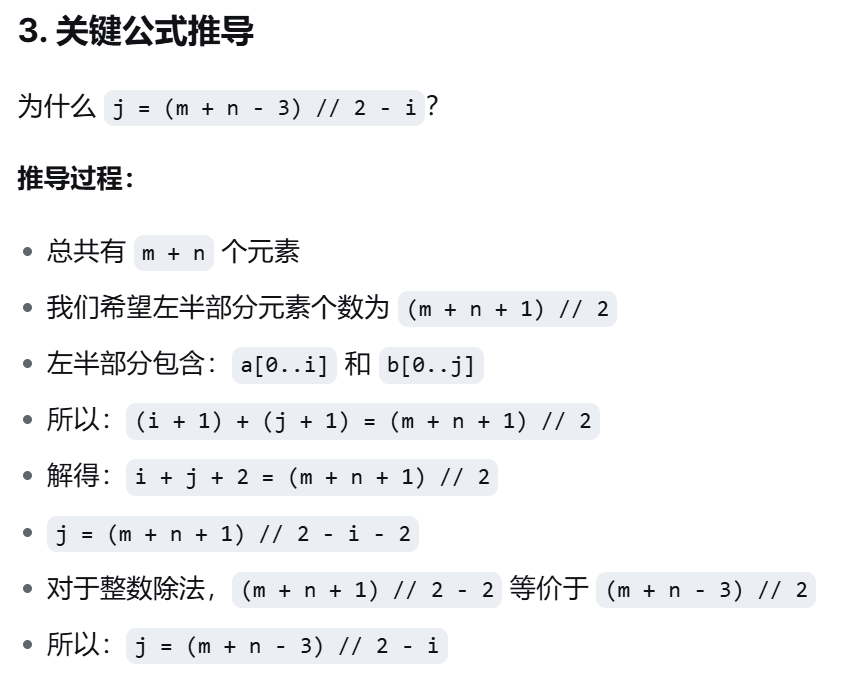

In [ ]:
from cmath import inf

class Solution:
    def findMedianSortedArrays(self, a, b) -> float:
        if len(a) > len(b):
            a, b = b, a

        m, n = len(a), len(b)
        # 循环不变量：a[left] <= b[j+1]
        # 循环不变量：a[right] > b[j+1]
        left, right = -1, m
        while left + 1 < right:  # 开区间 (left, right) 不为空
            i = (left + right) // 2
            j = (m + n - 3) // 2 - i
            #这里 i 表示数组 a 中左半部分的最后一个元素索引，j 表示数组 b 中左半部分的最后一个元素索引。
            if a[i] <= b[j + 1]:
                left = i  # 缩小二分区间为 (i, right)
            else:
                right = i  # 缩小二分区间为 (left, i)
        #对于left及其左边的值，满足a[i] <= b[j + 1]，对于right及其右边的值，满足a[i] > b[j + 1]
        #当循环结束时，left指向的就是a数组最后一个满足a[i]<=b[j+1]的元素，对于right而言，满足a[right] > b[j'+1] = b[j]，此时两个条件都满足，划分完成。


        # 此时 left 等于 right-1
        # a[left] <= b[j+1] 且 a[right] > b[j'+1] = b[j]，所以答案是 i=left
        i = left
        j = (m + n - 3) // 2 - i
        ai = a[i] if i >= 0 else -inf
        bj = b[j] if j >= 0 else -inf
        ai1 = a[i + 1] if i + 1 < m else inf
        bj1 = b[j + 1] if j + 1 < n else inf
        max1 = max(ai, bj)
        min2 = min(ai1, bj1)
        return max1 if (m + n) % 2 else (max1 + min2) / 2